In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# Load data 
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.info()
train_df.describe()
train_df.isnull().sum()

Train shape: (891, 12)
Test shape: (418, 11)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

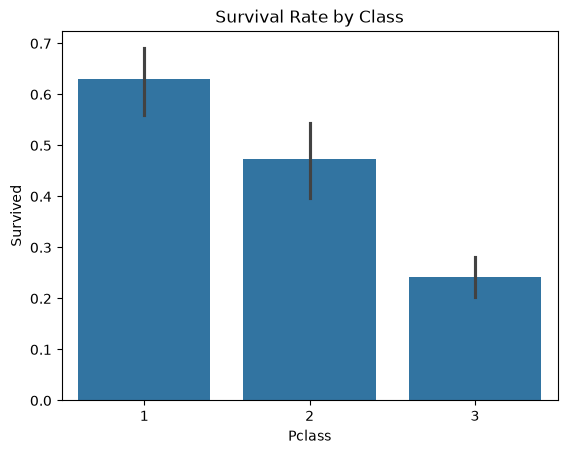

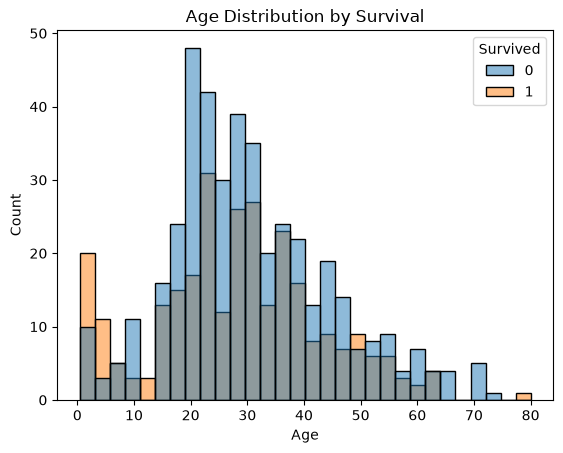

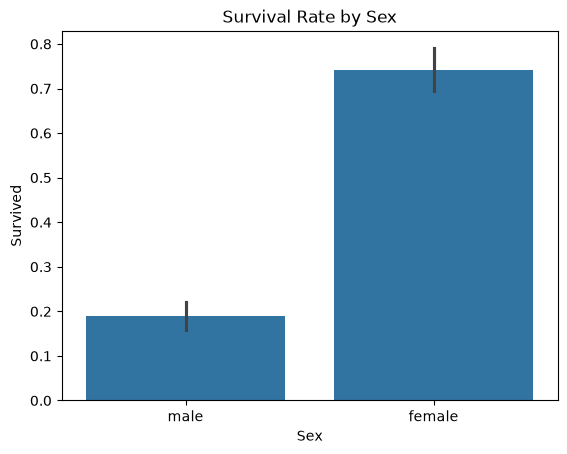

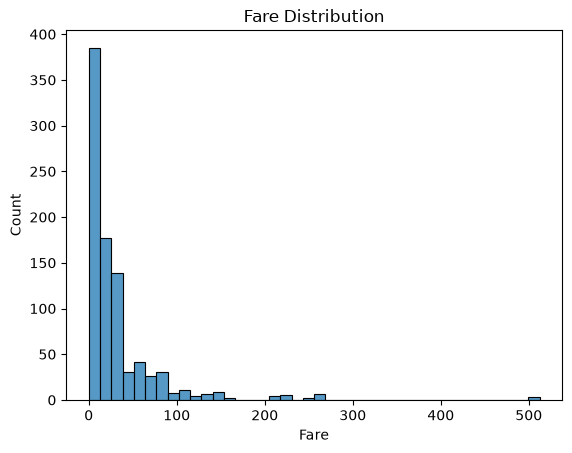

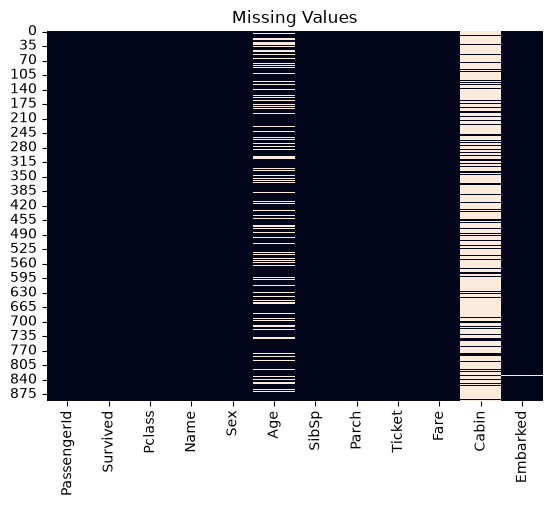

In [ ]:
#Survival by passenger class 
sns.barplot(x='Pclass', y='Survived', data=train_df)
plt.title('Survival Rate by Class')
plt.show()

# Age distribution: survived vs not 
sns.histplot(data=train_df, x='Age', hue='Survived', bins=30)
plt.title('Age Distribution by Survival')
plt.show()

# Survival by sex 
sns.barplot(x='Sex', y='Survived', data=train_df)
plt.title('Survival Rate by Sex')
plt.show()

# Fare distribution 
sns.histplot(data=train_df, x='Fare', bins=40)
plt.title('Fare Distribution')
plt.show()

# Missing data pattern 
sns.heatmap(train_df.isnull(), cbar=False)
plt.title('Missing Values')
plt.show()

In [ ]:
def fill_missing(df):
    df = df.copy()
    
    # Age: fill with median age
    df['Age'] = df['Age'].fillna(df['Age'].median())
    
    # Embarked: fill with most common value
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    
    # Fare: fill with median (test.csv has 1 missing)
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    
    # Cabin: too many missing, just convert to "has cabin or not"
    df['HasCabin'] = df['Cabin'].notnull().astype(int)
    
    return df

train_df2 = fill_missing(train_df)
test_df2 = fill_missing(test_df)

print(train_df2.isnull().sum())  

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
HasCabin         0
dtype: int64


In [ ]:
def add_features(df):
    df = df.copy()
    
    # Extract title from name 
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    
    # Group rare titles together
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'],
        'Rare'
    )
    df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})
    
    # Family size
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    return df

train_df3 = add_features(train_df2)
test_df3 = add_features(test_df2)

print(train_df3[['Name','Title','FamilySize']].head())

                                                Name Title  FamilySize
0                            Braund, Mr. Owen Harris    Mr           2
1  Cumings, Mrs. John Bradley (Florence Briggs Th...   Mrs           2
2                             Heikkinen, Miss. Laina  Miss           1
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)   Mrs           2
4                           Allen, Mr. William Henry    Mr           1


In [ ]:
def encode_and_clean(df):
    df = df.copy()
    
    # Sex: male=0, female=1
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    
    # One-hot encode Embarked and Title
    df = pd.get_dummies(df, columns=['Embarked', 'Title'], drop_first=True)
    
    # Drop columns we don't need anymore
    drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    
    return df

train_final = encode_and_clean(train_df3)
test_final = encode_and_clean(test_df3)

# Make sure train and test have the same columns 
train_cols = set(train_final.columns) - {'Survived'}
test_cols = set(test_final.columns)

for col in train_cols - test_cols:
    test_final[col] = 0
for col in test_cols - train_cols:
    test_final = test_final.drop(columns=[col])

print(train_final.columns.tolist())
print(train_final.head())
print(train_final.shape, test_final.shape)

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  HasCabin  FamilySize  \
0         0       3    0  22.0      1      0   7.2500         0           2   
1         1       1    1  38.0      1      0  71.2833         1           2   
2         1       3    1  26.0      0      0   7.9250         0           1   
3         1       1    1  35.0      1      0  53.1000         1           2   
4         0       3    0  35.0      0      0   8.0500         0           1   

   Embarked_Q  Embarked_S  Title_Miss  Title_Mr  Title_Mrs  Title_Rare  
0       False        True       False      True      False       False  
1       False       False       False     False       True       False  
2       False        True        True     False      False       False  
3       False        True       False     False       True     

In [ ]:
# Convert boolean columns to int 
bool_cols = train_final.select_dtypes(include='bool').columns
train_final[bool_cols] = train_final[bool_cols].astype(int)

bool_cols_test = test_final.select_dtypes(include='bool').columns
test_final[bool_cols_test] = test_final[bool_cols_test].astype(int)

print(train_final.dtypes)

Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
HasCabin        int64
FamilySize      int64
Embarked_Q      int64
Embarked_S      int64
Title_Miss      int64
Title_Mr        int64
Title_Mrs       int64
Title_Rare      int64
dtype: object


In [ ]:
def gini_impurity(y):
    if len(y) == 0:
        return 0
    
    p1 = np.mean(y)       
    p0 = 1 - p1           
    return 1 - (p0**2 + p1**2)

# Quick test
test1 = np.array([0,0,0,0])      
test2 = np.array([0,1,0,1])       
print(gini_impurity(test1))
print(gini_impurity(test2))

def split_data(X, y, feature_idx, threshold):
    left_mask = X[:, feature_idx] <= threshold
    right_mask = ~left_mask
    return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

# Quick test with dummy data
X_test = np.array([[1],[2],[3],[4]])
y_test = np.array([0,0,1,1])
Xl, yl, Xr, yr = split_data(X_test, y_test, 0, 2.5)
print("Left y:", yl)   # should be [0,0]
print("Right y:", yr)  # should be [1,1]

def best_split(X, y):
    n_samples, n_features = X.shape
    parent_impurity = gini_impurity(y)
    
    best_gain = -1
    best_feature = None
    best_threshold = None
    
    for feature_idx in range(n_features):
        thresholds = np.unique(X[:, feature_idx])
        
        for threshold in thresholds:
            _, y_left, _, y_right = split_data(X, y, feature_idx, threshold)
            
            if len(y_left) == 0 or len(y_right) == 0:
                continue  # skip splits that don't actually divide the data
            
            # Weighted impurity of children
            n = len(y)
            weighted_impurity = (len(y_left)/n) * gini_impurity(y_left) + \
                                 (len(y_right)/n) * gini_impurity(y_right)
            
            gain = parent_impurity - weighted_impurity
            
            if gain > best_gain:
                best_gain = gain
                best_feature = feature_idx
                best_threshold = threshold
    
    return best_feature, best_threshold, best_gain

# Quick test
X_test = np.array([[1],[2],[3],[4]])
y_test = np.array([0,0,1,1])
feat, thresh, gain = best_split(X_test, y_test)
print("Best feature:", feat, "| Best threshold:", thresh, "| Gain:", gain)


class Node:
    """One node in the tree. If value is set, it's a leaf (prediction). Otherwise it's a split."""
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None


class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _majority_class(self, y):
        # Returns whichever class (0 or 1) appears more often
        return 1 if np.mean(y) >= 0.5 else 0

    def _build_tree(self, X, y, depth=0):
        n_samples = len(y)
        n_classes = len(np.unique(y))

        # Stop growing if: pure node, too few samples, or max depth hit
        if n_classes == 1 or n_samples < self.min_samples_split or \
           (self.max_depth is not None and depth >= self.max_depth):
            return Node(value=self._majority_class(y))

        feature, threshold, gain = best_split(X, y)

        # No useful split found -> make this a leaf
        if feature is None or gain <= 0:
            return Node(value=self._majority_class(y))

        X_left, y_left, X_right, y_right = split_data(X, y, feature, threshold)

        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)

        return Node(feature=feature, threshold=threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.root = self._build_tree(X, y)
        return self

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(x, self.root) for x in X])

X_test = np.array([[1],[2],[3],[4]])
y_test = np.array([0,0,1,1])

tree = DecisionTree(max_depth=3)
tree.fit(X_test, y_test)
preds = tree.predict(X_test)
print("Predictions:", preds)
print("Actual:     ", y_test)
print("Accuracy:", np.mean(preds == y_test))

0.0
0.5
Left y: [0 0]
Right y: [1 1]
Best feature: 0 | Best threshold: 2 | Gain: 0.5
Predictions: [0 0 1 1]
Actual:      [0 0 1 1]
Accuracy: 1.0


In [ ]:
# Prepare X and y from the real data
X = train_final.drop(columns=['Survived']).values.astype(float)
y = train_final['Survived'].values.astype(int)
feature_names = train_final.drop(columns=['Survived']).columns.tolist()

# Split into train/validation 
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Val size:", X_val.shape)

# Train a single tree
tree = DecisionTree(max_depth=5, min_samples_split=5)
tree.fit(X_train, y_train)

# Check training and validation accuracy
train_preds = tree.predict(X_train)
val_preds = tree.predict(X_val)

print("Train accuracy:", np.mean(train_preds == y_train))
print("Val accuracy:", np.mean(val_preds == y_val))

Train size: (712, 14)
Val size: (179, 14)
Train accuracy: 0.8693820224719101
Val accuracy: 0.770949720670391


In [ ]:
from collections import Counter

class RandomForest:
    def __init__(self, n_estimators=100, max_depth=None, min_samples_split=2, max_features='sqrt'):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.trees = []
        self.tree_feature_subsets = []  # which features each tree used

    def _bootstrap_sample(self, X, y):
        # Sample n rows WITH replacement (some rows repeat, some left out)
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        return X[indices], y[indices]

    def _random_features(self, n_total_features):
        # Pick a random subset of feature indices (sqrt(n) is the standard choice)
        if self.max_features == 'sqrt':
            k = max(1, int(np.sqrt(n_total_features)))
        else:
            k = n_total_features
        return np.random.choice(n_total_features, size=k, replace=False)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        n_total_features = X.shape[1]

        self.trees = []
        self.tree_feature_subsets = []

        for i in range(self.n_estimators):
            # 1. Bootstrap sample the rows
            X_sample, y_sample = self._bootstrap_sample(X, y)

            # 2. Pick a random subset of feature columns for this tree
            feature_subset = self._random_features(n_total_features)
            X_sample_subset = X_sample[:, feature_subset]

            # 3. Train a tree on this sample using only those features
            tree = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X_sample_subset, y_sample)

            self.trees.append(tree)
            self.tree_feature_subsets.append(feature_subset)

        return self

    def predict(self, X):
        X = np.asarray(X)
        n_samples = X.shape[0]

        # Collect predictions from every tree 
        all_preds = []
        for tree, feature_subset in zip(self.trees, self.tree_feature_subsets):
            X_subset = X[:, feature_subset]
            all_preds.append(tree.predict(X_subset))
        all_preds = np.array(all_preds)  # shape: (n_trees, n_samples)

        # Majority vote for each sample
        final_preds = np.array([
            Counter(all_preds[:, i]).most_common(1)[0][0]
            for i in range(n_samples)
        ])
        return final_preds
rf = RandomForest(n_estimators=50, max_depth=6, min_samples_split=5)
rf.fit(X_train, y_train)

train_preds = rf.predict(X_train)
val_preds = rf.predict(X_val)

print("Train accuracy:", np.mean(train_preds == y_train))
print("Val accuracy:", np.mean(val_preds == y_val))

Train accuracy: 0.8370786516853933
Val accuracy: 0.7821229050279329


In [16]:
def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

def precision_recall_f1(y_true, y_pred):
    tp, tn, fp, fn = confusion_matrix_manual(y_true, y_pred)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

tp, tn, fp, fn = confusion_matrix_manual(y_val, val_preds)
precision, recall, f1 = precision_recall_f1(y_val, val_preds)

print(f"TP={tp}, TN={tn}, FP={fp}, FN={fn}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

TP=42, TN=98, FP=12, FN=27
Precision: 0.7778
Recall:    0.6087
F1-score:  0.6829


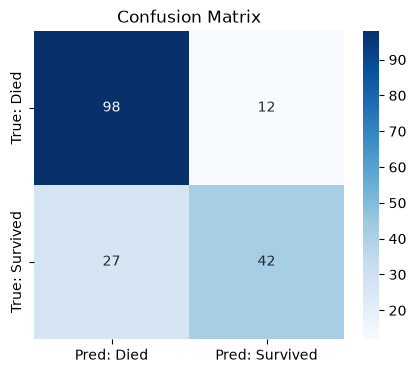

AUC: 0.8183


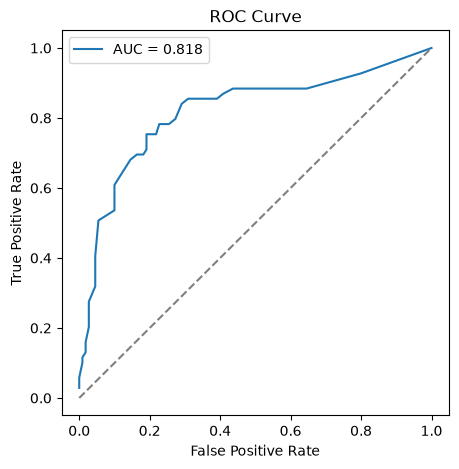

In [ ]:
#Confusion matrix plot 
cm = np.array([[tn, fp],
               [fn, tp]])

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Died','Pred: Survived'],
            yticklabels=['True: Died','True: Survived'])
plt.title('Confusion Matrix')
plt.show()


#  AUC (manual ROC curve) 
def roc_auc_manual(y_true, y_scores):
    thresholds = np.sort(np.unique(y_scores))[::-1]
    tpr_list, fpr_list = [], []
    
    P = np.sum(y_true == 1)  # total actual positives
    N = np.sum(y_true == 0)  # total actual negatives
    
    for t in thresholds:
        y_pred_t = (y_scores >= t).astype(int)
        tp = np.sum((y_true == 1) & (y_pred_t == 1))
        fp = np.sum((y_true == 0) & (y_pred_t == 1))
        tpr_list.append(tp / P if P > 0 else 0)
        fpr_list.append(fp / N if N > 0 else 0)
    
    # Sort by FPR so we can integrate area under curve
    order = np.argsort(fpr_list)
    fpr_arr = np.array(fpr_list)[order]
    tpr_arr = np.array(tpr_list)[order]
    
    # np.trapz was renamed to np.trapezoid in newer NumPy — handle both
    if hasattr(np, 'trapezoid'):
        auc = np.trapezoid(tpr_arr, fpr_arr)
    else:
        auc = np.trapz(tpr_arr, fpr_arr)
    
    return auc, fpr_arr, tpr_arr


# We need prediction PROBABILITIES (not just 0/1) for AUC
def predict_proba(forest, X):
    X = np.asarray(X)
    all_preds = []
    for tree, feature_subset in zip(forest.trees, forest.tree_feature_subsets):
        X_subset = X[:, feature_subset]
        all_preds.append(tree.predict(X_subset))
    all_preds = np.array(all_preds)
    # Fraction of trees that voted "1" for each sample = probability of survival
    return np.mean(all_preds, axis=0)

val_probs = predict_proba(rf, X_val)
auc, fpr_arr, tpr_arr = roc_auc_manual(y_val, val_probs)
print(f"AUC: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(5,5))
plt.plot(fpr_arr, tpr_arr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [19]:
results = []

n_estimators_list = [10, 50, 100, 200]
max_depth_list = [3, 5, 10, None]
min_samples_split_list = [2, 5, 10]

for n_est in n_estimators_list:
    for max_d in max_depth_list:
        for min_split in min_samples_split_list:
            
            model = RandomForest(
                n_estimators=n_est,
                max_depth=max_d,
                min_samples_split=min_split,
                max_features='sqrt'
            )
            model.fit(X_train, y_train)
            
            preds = model.predict(X_val)
            acc = np.mean(preds == y_val)
            
            results.append({
                'n_estimators': n_est,
                'max_depth': max_d,
                'min_samples_split': min_split,
                'val_accuracy': acc
            })
            
            print(f"n_estimators={n_est}, max_depth={max_d}, min_split={min_split} -> acc={acc:.4f}")

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('val_accuracy', ascending=False)
print("\nTop 10 combinations:")
print(results_df.head(10))

n_estimators=10, max_depth=3, min_split=2 -> acc=0.7933
n_estimators=10, max_depth=3, min_split=5 -> acc=0.7542
n_estimators=10, max_depth=3, min_split=10 -> acc=0.7095
n_estimators=10, max_depth=5, min_split=2 -> acc=0.7821
n_estimators=10, max_depth=5, min_split=5 -> acc=0.7374
n_estimators=10, max_depth=5, min_split=10 -> acc=0.7654
n_estimators=10, max_depth=10, min_split=2 -> acc=0.7765
n_estimators=10, max_depth=10, min_split=5 -> acc=0.8045
n_estimators=10, max_depth=10, min_split=10 -> acc=0.7765
n_estimators=10, max_depth=None, min_split=2 -> acc=0.7207
n_estimators=10, max_depth=None, min_split=5 -> acc=0.7933
n_estimators=10, max_depth=None, min_split=10 -> acc=0.7654
n_estimators=50, max_depth=3, min_split=2 -> acc=0.7598
n_estimators=50, max_depth=3, min_split=5 -> acc=0.7821
n_estimators=50, max_depth=3, min_split=10 -> acc=0.7039
n_estimators=50, max_depth=5, min_split=2 -> acc=0.7933
n_estimators=50, max_depth=5, min_split=5 -> acc=0.8101
n_estimators=50, max_depth=5, m

Final model validation accuracy: 0.7541899441340782
       feature  importance
5         Fare    0.271006
1          Sex    0.140090
2          Age    0.122931
12   Title_Mrs    0.100164
11    Title_Mr    0.083479
0       Pclass    0.062272
7   FamilySize    0.060090
10  Title_Miss    0.041348
6     HasCabin    0.035875
3        SibSp    0.029921
4        Parch    0.021209
9   Embarked_S    0.018636
8   Embarked_Q    0.008786
13  Title_Rare    0.004194


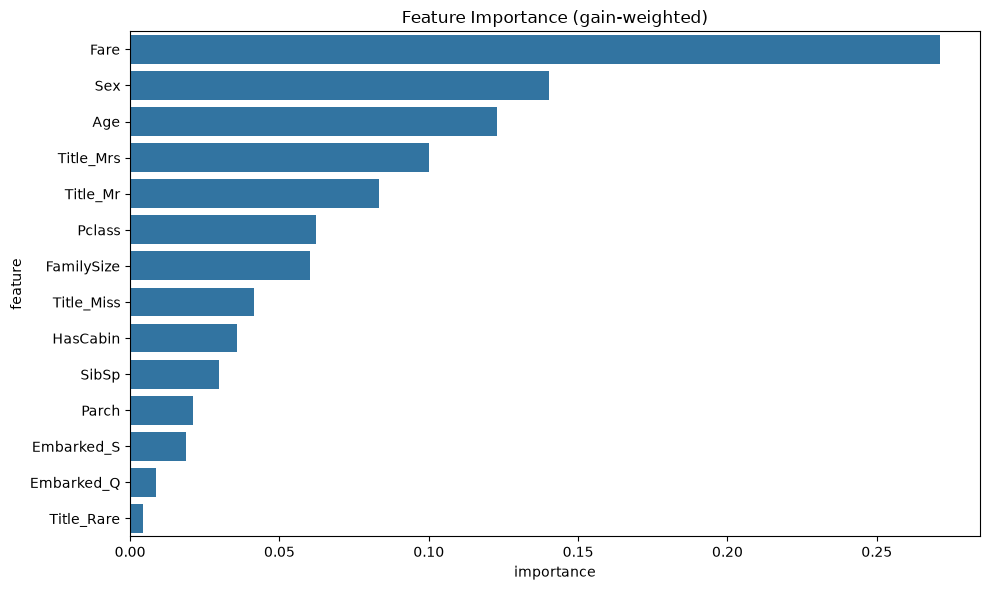

In [ ]:
np.random.seed(42)  # lock randomness so results are reproducible


class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None,
                 value=None, gain=None, n_samples=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        self.gain = gain
        self.n_samples = n_samples

    def is_leaf(self):
        return self.value is not None


class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def _majority_class(self, y):
        return 1 if np.mean(y) >= 0.5 else 0

    def _build_tree(self, X, y, depth=0):
        n_samples = len(y)
        n_classes = len(np.unique(y))

        if n_classes == 1 or n_samples < self.min_samples_split or \
           (self.max_depth is not None and depth >= self.max_depth):
            return Node(value=self._majority_class(y))

        feature, threshold, gain = best_split(X, y)

        if feature is None or gain <= 0:
            return Node(value=self._majority_class(y))

        X_left, y_left, X_right, y_right = split_data(X, y, feature, threshold)
        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)

        return Node(feature=feature, threshold=threshold, left=left_child, right=right_child,
                     gain=gain, n_samples=n_samples)

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.root = self._build_tree(X, y)
        return self

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(x, self.root) for x in X])



def get_feature_importance_by_gain(node, feature_subset, importance):
    if node.is_leaf():
        return
    original_feature_idx = feature_subset[node.feature]
    importance[original_feature_idx] += node.gain * node.n_samples
    get_feature_importance_by_gain(node.left, feature_subset, importance)
    get_feature_importance_by_gain(node.right, feature_subset, importance)


final_rf = RandomForest(n_estimators=50, max_depth=10, min_samples_split=5, max_features='sqrt')
final_rf.fit(X_train, y_train)

final_preds = final_rf.predict(X_val)
final_acc = np.mean(final_preds == y_val)
print("Final model validation accuracy:", final_acc)


n_features = X_train.shape[1]
importance = np.zeros(n_features)

for tree, feature_subset in zip(final_rf.trees, final_rf.tree_feature_subsets):
    get_feature_importance_by_gain(tree.root, feature_subset, importance)

importance = importance / importance.sum()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print(importance_df)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Feature Importance (gain-weighted)')
plt.tight_layout()
plt.show()